In [1]:
#!pip install ipywidgets
from huggingface_hub import login
login()

In [1]:
from huggingface_hub import whoami

try:
    info = whoami()
    print("Eingeloggt als:", info["name"])
except Exception:
    print("Nicht eingeloggt")

Eingeloggt als: axel98


In [1]:
from models.mllm_wrappers import LLaVA, Qwen, Janus, Qwen3_5, Molmo, Qwen3_5_vLLM, Qwen3_5_GGUF2
from configuration_template import Config

config_background = Config(model="Qwen/Qwen2-VL-2B-Instruct")
config_background.input_type = 'simple'
config_background.task = 'grid'

img_kwargs = {
        "patch_size": config_background.patch_size,
        "patch_padding": config_background.patch_padding,
        "patch_pad_color": config_background.patch_pad_color,
    }

generate_kwargs = {
        "max_new_tokens": config_background.max_new_tokens,
        "do_sample": True,
        "temperature": 0.8
    }

model_kwargs = {"cache_dir": config_background.model_cache_dir, "quant": config_background.quant}

Model = Qwen
model_background = Model(config_background.model_id, **model_kwargs)
print(f'Model: {model_background.__class__}')

model_version: Qwen2
model_type: Qwen
/home/alesau/mllm/mllm/PATH
building Qwen model...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

/home/alesau/miniconda3/envs/mllm/lib/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Model: <class 'models.mllm_wrappers.Qwen'>


In [1]:
from models.mllm_wrappers import LLaVA, Qwen, Janus, Qwen3_5, Molmo, Qwen3_5_vLLM, Qwen3_5_GGUF2
from configuration_template import Config

config = Config(model="Qwen/Qwen3.5-0.8B")
config.input_type = 'simple'
config.task = 'patch'

img_kwargs = {
        "patch_size": config.patch_size,
        "patch_padding": config.patch_padding,
        "grid_padding": config.grid_padding,
        "patch_pad_color": config.patch_pad_color,
        "grid_pad_color": config.grid_pad_color,
    }

generate_kwargs = {
        "max_new_tokens": config.max_new_tokens,
        "do_sample": True,
        "temperature": 0.8
    }

model_kwargs = {"cache_dir": config.model_cache_dir, "quant": config.quant}


print("Model ID: ", config.model_id)



model_version: Qwen3.5
model_type: Qwen3_5
/home/alesau/mllm/mllm/PATH
Model ID:  Qwen/Qwen3.5-0.8B


In [4]:
#!pip install optimum
#!pip install -U optimum torch auto-gptq accelerate
#!pip install --upgrade accelerate optimum transformers
#!pip install "protobuf>=5.0,<7.0"
#!pip install gptqmodel --no-build-isolation
import sys
python_version = f"{sys.version_info.major}.{sys.version_info.minor}"
print(f"Python version: {python_version}")

Python version: 3.14


In [5]:
#!pip install vllm
#!pip install llama-cpp-python

In [ ]:
import optimum

Model = Qwen3_5_GGUF2
#model = Model(config.model_id, **model_kwargs)

model_kwargs = {
    "model_path": "/home/alesau/mllm/mllm/PATH/Qwen3.5-27B-UD-Q4_K_XL.gguf",
    "mmproj_path": "/home/alesau/mllm/mllm/PATH/mmproj-BF16.gguf",

    "n_gpu_layers": -1,
    "n_ctx": 2048,
    "n_batch": 1024,
    "n_ubatch": 512,
}

model = Model(**model_kwargs)

print(f'Model: {model.__class__}')

building Qwen3_5_GGUF2 model with llama.cpp...
Model: <class 'models.mllm_wrappers.Qwen3_5_GGUF2'>


In [3]:
model_kwargs = {"cache_dir": config.model_cache_dir, "quant": config.quant}

Model = Qwen3_5
model = Model(config.model_id, **model_kwargs)
print(f'Model: {model.__class__}')

building Qwen3_5 model...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Model: <class 'models.mllm_wrappers.Qwen3_5'>


In [3]:
from bert_score import BERTScorer
from peft import LoraConfig, get_peft_model

hf_model = model.model
processor = model.processor

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,

    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],

    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

hf_model = get_peft_model(hf_model, lora_config)

hf_model.print_trainable_parameters()


scorer = BERTScorer(lang="en", rescale_with_baseline=True)

trainable params: 3,932,160 || all params: 9,413,745,904 || trainable%: 0.0418


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:

print(type(model))
print(model.__dict__.keys())
print(type(model.model))
print(type(model.processor))
print(model.model_size)

<class 'models.mllm_wrappers.Qwen3_5'>
dict_keys(['model', 'processor', 'model_id', 'model_size', 'quant', 'device'])
<class 'transformers.models.qwen3_5.modeling_qwen3_5.Qwen3_5ForConditionalGeneration'>
<class 'transformers.models.qwen3_vl.processing_qwen3_vl.Qwen3VLProcessor'>
9b


In [3]:
from openai import OpenAI

#model = OpenAI(
#    api_key="EMPTY",
#    base_url="http://129.70.40.28:8000/v1",
#)

model = OpenAI(
    api_key="EMPTY",
    base_url="http://0.0.0.0:8080/v1",
) 
response = model.chat.completions.create(
    model="Qwen/Qwen3.6-27B-FP8",
    messages=[
        {
            "role": "user",
            "content": "Beschreibe die Farbe Türkis in max 3 Sätzen"
        }
    ],
    temperature=0.7,
    max_tokens=800,
    extra_body={
        "chat_template_kwargs": {
            "enable_thinking": True
        }
    }
)

print(response.choices[0].message.content)

Türkis ist eine leuchtende Mischung aus Blau und Grün, die an klares Meerwasser erinnert. Sie wirkt frisch, kühl und angenehm, ohne zu kalt oder zu warm zu sein. In der Natur taucht sie in Lagunen, Edelsteinen und dem Himmel auf.


In [6]:
import vllm
import torch

print(vllm.__version__)
print(torch.__version__)

0.22.1
2.11.0+cu130


In [ ]:
## set randomness
model_mode = 'random'

if model_mode == 'random':
    ## set randomness
    model.model.generation_config.temperature = 0.7
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.9
    model.model.generation_config.top_k = 50
else:
    ## set deterministic
    model.model.generation_config.temperature = 0.01
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.001
    model.model.generation_config.top_k = 1

: 

In [2]:
import pandas as pd
import os.path as osp

def utterances_to_dialogue_string(utterances):
    lines = [f'{intl}: {utt}' for intl, utt, _ in utterances]
    return '\n'.join(lines)

#data_df = pd.read_json(osp.join(config.data_dir, "color_patch_data.json"))
data_df = pd.read_json(osp.join(config.data_dir, "color_grid_data.json"))

In [3]:
prompt = "You got an image with three color patches and a conversation between a Speaker and a Listener. One of them is described by the Speaker and you see the patches in the order they were presented to the Listener. Identify which patch is described and just answer with left, middle or right. Keep in mind, that the Listener and the Speaker can see a different order of the three patches. Do not explain yourself. Just answer with left, middle or right. This is the conversation: \n"
prompt_2 = "\n Is it the left, middle or right patch?"

In [3]:
prompt = "You got an image with three color grids and a conversation between a Speaker and a Listener. One of them is described by the Speaker and you see the grids in the order they were presented to the Listener. Identify which grid is described and just answer with left, middle or right. Keep in mind, that the Listener and the Speaker can see a different order of the three grids. Do not explain yourself. Just answer with left, middle or right. This is the conversation: \n"
prompt_2 = "\n Is it the left, middle or right patch?"

In [4]:
### patches

from data_prep.data_utils import build_patch_image_with_target_highlight

images = list()
conversations = list()
targets = list()
accuracy_listener = list()
entrys = list()

entry_printed = False
for i, entry in data_df.sample(n=1400, random_state=42).iterrows():
    #print(f'Entry {i}:')
    if entry.success == True and len(conversations) < 1000:
        images.append(build_patch_image_with_target_highlight(entry.hls_values, entry.l_order_t_distr1_distr2, **img_kwargs, highlight_target=False))
        conversations.append(utterances_to_dialogue_string(entry.conversation))
        targets.append(entry.l_order_t_distr1_distr2.index(0))
        accuracy_listener.append(entry.success)
        entrys.append(entry)
    # print(f'Utterances: {utterances_to_dialogue_string(entry.conversation)}')
    # print(f'Target: {entry.l_order_t_distr1_distr2.index(0)}')
    #print('---')

In [3]:
###grids

from data_prep.data_utils import build_grid_image
images = list()
conversations = list()
targets = list()
accuracy_listener = list()
entrys = list()

entry_printed = False
for i, entry in data_df.sample(n=1400, random_state=42).iterrows():
    #print(f'Entry {i}:')
    if entry.success == True and len(conversations) < 1000:
        images.append(build_grid_image(entry.objs, entry.listener_order, **img_kwargs))
        conversations.append(utterances_to_dialogue_string(entry.utterances))
        targets.append(entry.listener_order.index(entry.target))
        accuracy_listener.append(entry.success)
        entrys.append(entry)
    # print(f'Utterances: {utterances_to_dialogue_string(entry.conversation)}')
    # print(f'Target: {entry.l_order_t_distr1_distr2.index(0)}')
    #print('---')

In [4]:
num_close, num_split, num_far = 0, 0, 0
for entry in entrys:
    #print("Entry condition:", entry.condition)
    if entry.condition.lower() == 'close':
        num_close += 1
    elif entry.condition.lower() == 'split':
        num_split += 1
    elif entry.condition.lower() == 'far':
        num_far += 1

print(f'Number of close: {num_close}, Number of split: {num_split}, Number of far: {num_far}')

Number of close: 334, Number of split: 318, Number of far: 348


Entry 0:


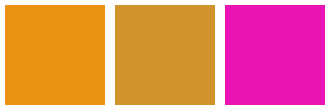

Utterances: speaker: bright orange
Listener order: [0, 1, 2]
Target: 0
---
Entry 1:


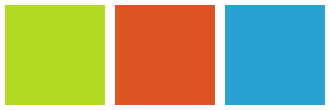

Utterances: speaker: blue
Listener order: [1, 2, 0]
Target: 2
---
Entry 2:


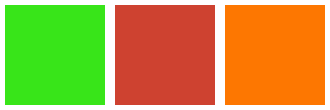

Utterances: speaker: Red
Listener order: [1, 0, 2]
Target: 1
---
Entry 3:


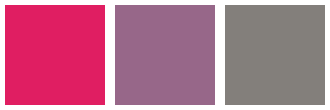

Utterances: speaker: mauve
Listener order: [1, 0, 2]
Target: 1
---
Entry 4:


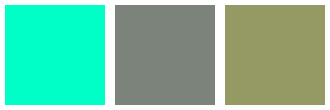

Utterances: speaker: the grey with purple tint?
Listener order: [0, 2, 1]
Target: 0
---
Entry 5:


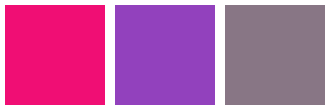

Utterances: speaker: pink
Listener order: [0, 2, 1]
Target: 0
---
Entry 6:


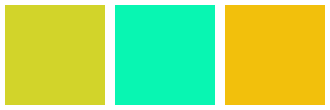

Utterances: speaker: school bus yellow
Listener order: [1, 2, 0]
Target: 2
---
Entry 7:


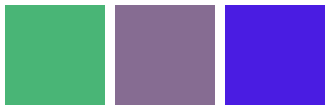

Utterances: speaker: grey
Listener order: [1, 0, 2]
Target: 1
---
Entry 8:


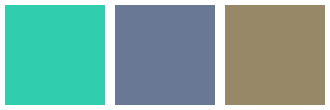

Utterances: speaker: dark purple
Listener order: [1, 0, 2]
Target: 1
---
Entry 9:


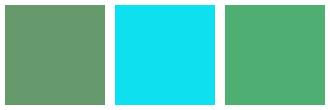

Utterances: speaker: brighter green
Listener order: [1, 2, 0]
Target: 2
---
Entry 10:


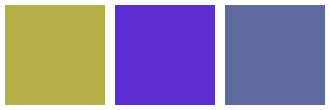

Utterances: speaker: muted purple
Listener order: [2, 1, 0]
Target: 2
---


In [6]:
### patches

for i, entry in enumerate(entrys):
    print(f'Entry {i}:')
    img = build_patch_image_with_target_highlight(entry.hls_values, entry.l_order_t_distr1_distr2, **img_kwargs, highlight_target=False)
    display(img)
    print(f'Utterances: {utterances_to_dialogue_string(entry.conversation)}')
    print(f'Listener order: {entry.l_order_t_distr1_distr2}')
    print(f'Target: {entry.l_order_t_distr1_distr2.index(0)}')
    #print(f"Prediction: {predicted_targets[i] if i < len(predicted_targets) else 'N/A'}")
    print('---')

    if i >= 10:
        break

Entry 0:


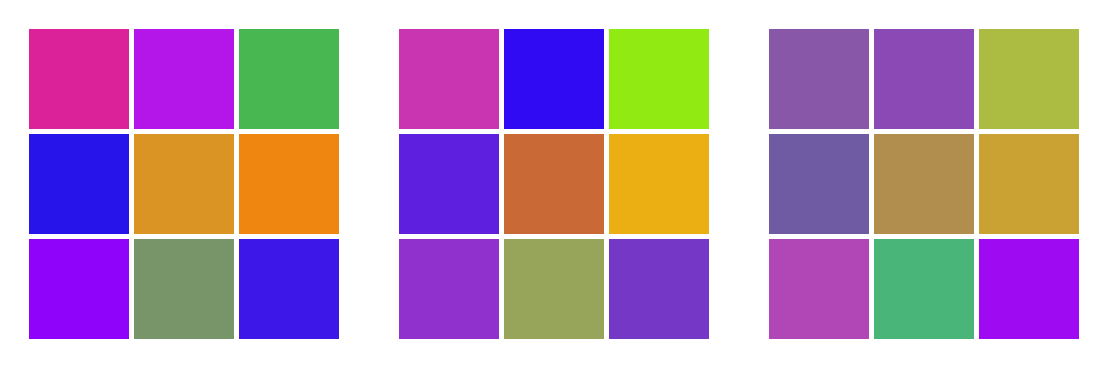

Utterances: speaker: there are only 2 purple squares total
Listener order: [0, 2, 1]
Target: 0
---
Entry 1:


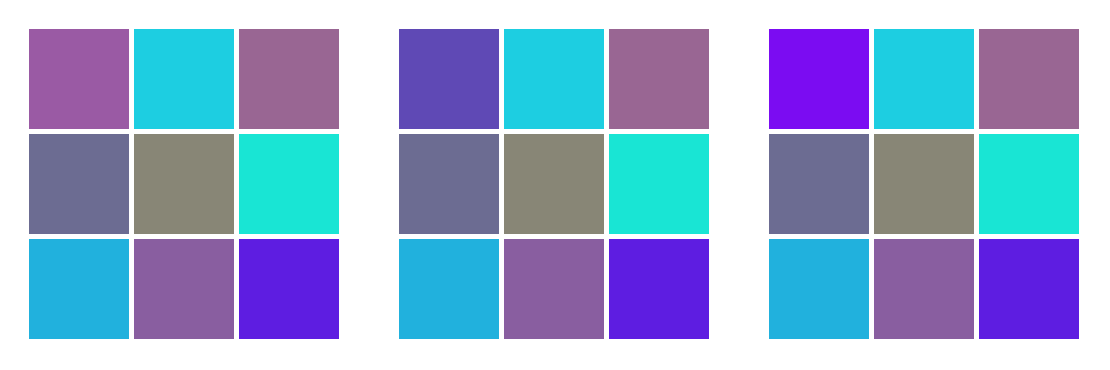

Utterances: speaker: 1 dark blue
Listener order: [2, 0, 1]
Target: 1
---
Entry 2:


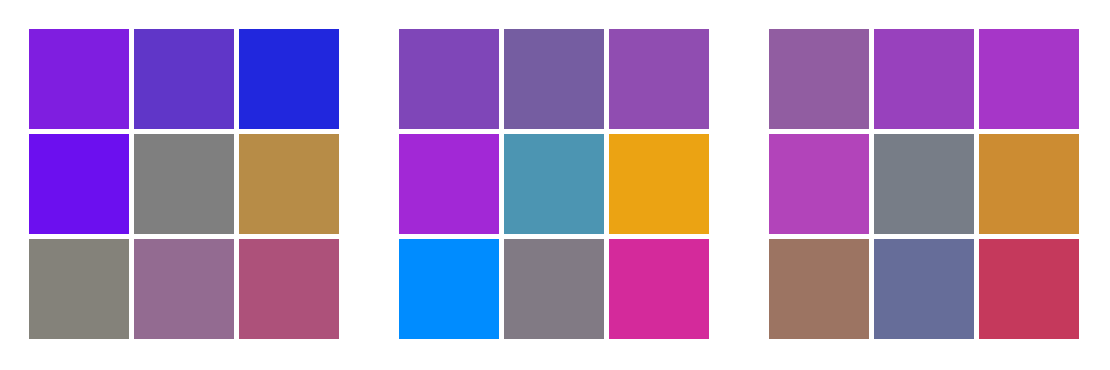

Utterances: speaker: Top right is blue
Listener order: [2, 0, 1]
Target: 0
---
Entry 3:


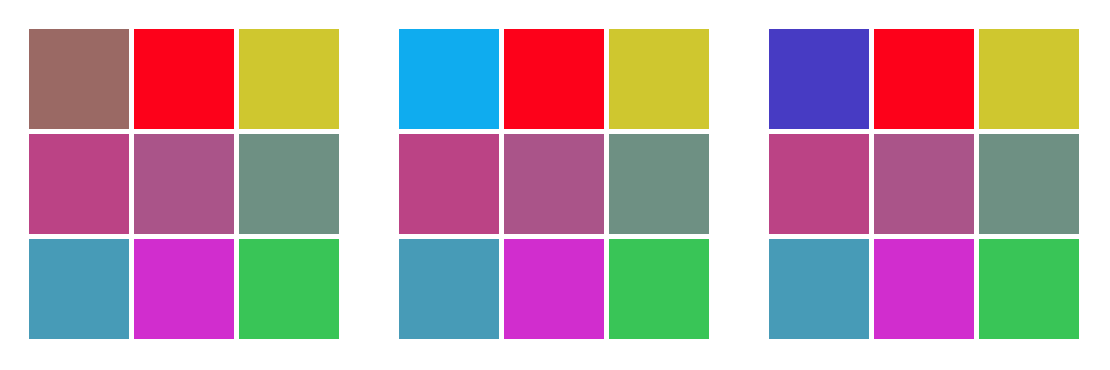

Utterances: speaker: 1 dark blue
Listener order: [1, 2, 0]
Target: 2
---
Entry 4:


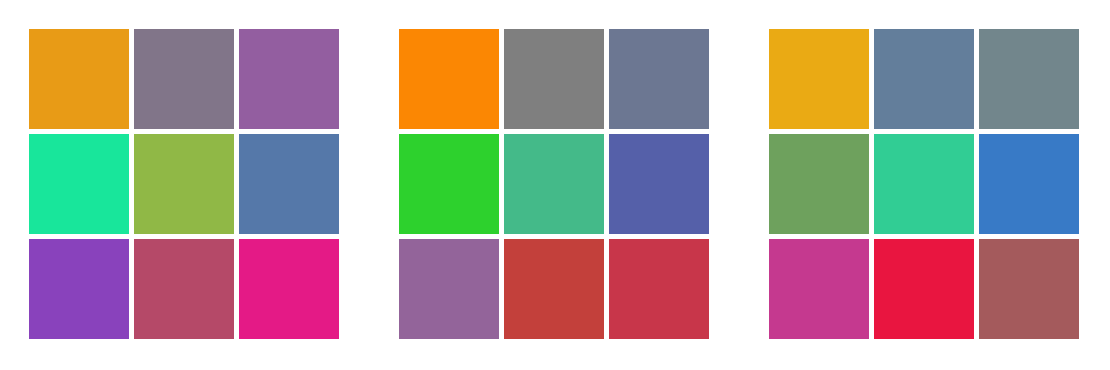

Utterances: speaker: um
speaker: lol
listener: right
speaker: bottom middle is brick red, and next to that is almost brown
speaker: almost brown on the right of it.~~~~~~
listener: grey or purple on left
speaker: purple [ish]
Listener order: [1, 2, 0]
Target: 2
---
Entry 5:


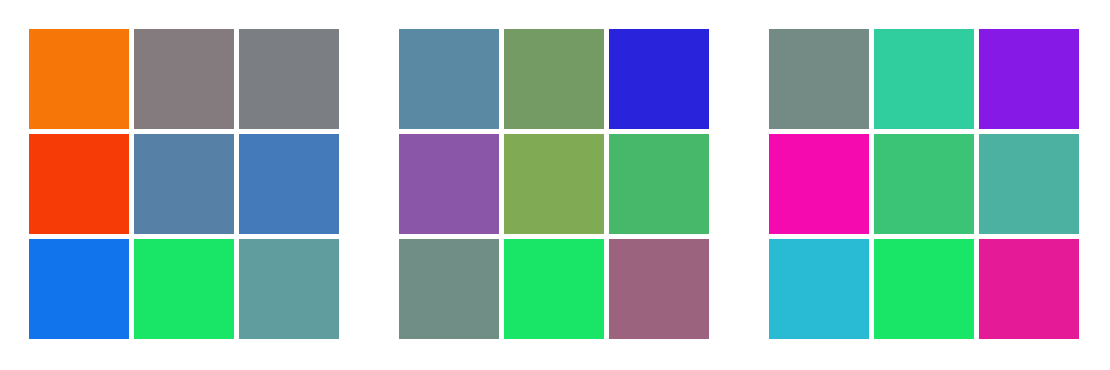

Utterances: speaker: Middle left is bright pink, bottom right is also a brighter pink
Listener order: [0, 1, 2]
Target: 2
---
Entry 6:


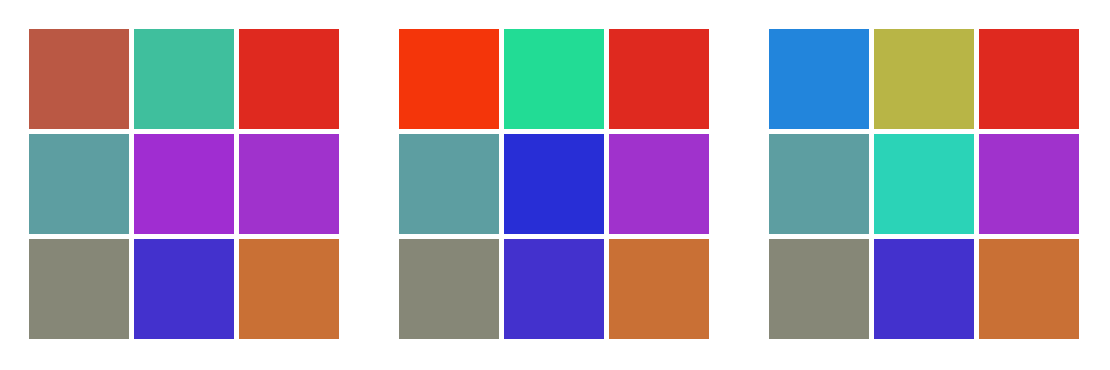

Utterances: speaker: it has a dark blue middle
Listener order: [1, 0, 2]
Target: 1
---
Entry 7:


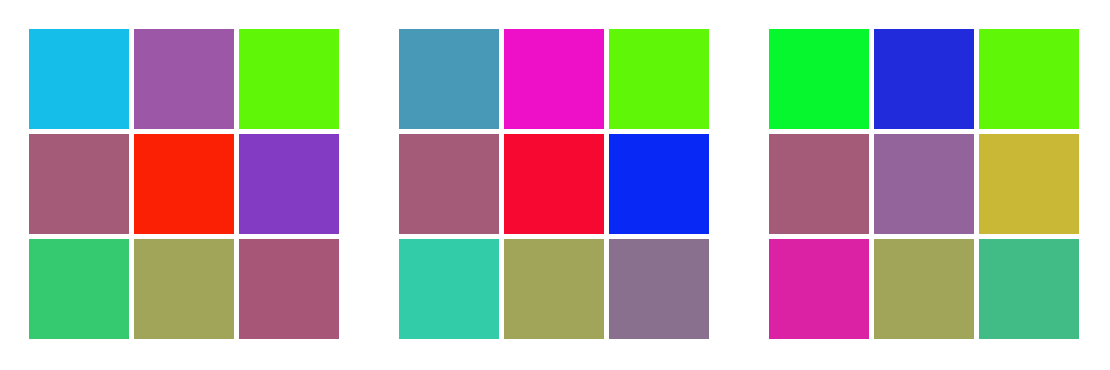

Utterances: speaker: Top middle is pink with green next to it
Listener order: [1, 0, 2]
Target: 1
---
Entry 8:


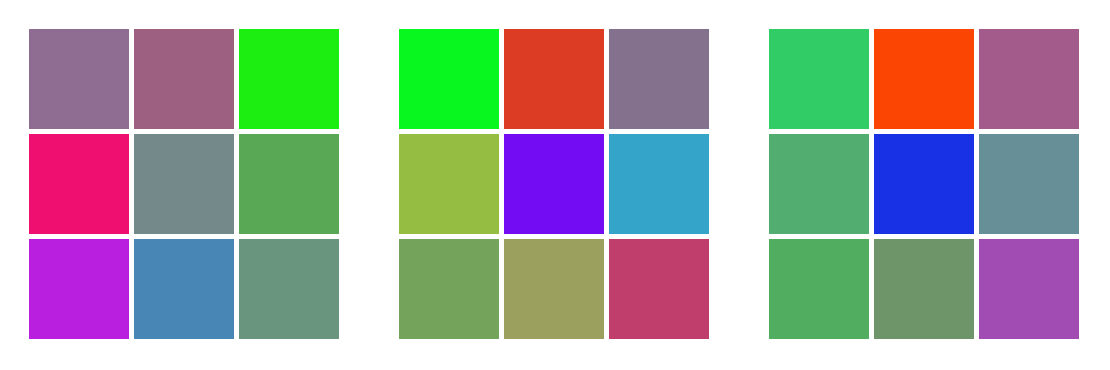

Utterances: speaker: green top left
Listener order: [1, 0, 2]
Target: 1
---
Entry 9:


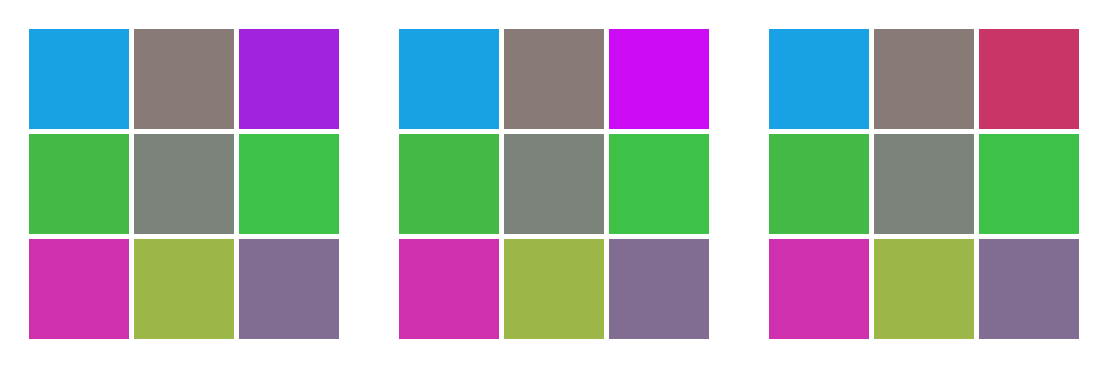

Utterances: speaker: Bright purple top right
Listener order: [2, 1, 0]
Target: 1
---
Entry 10:


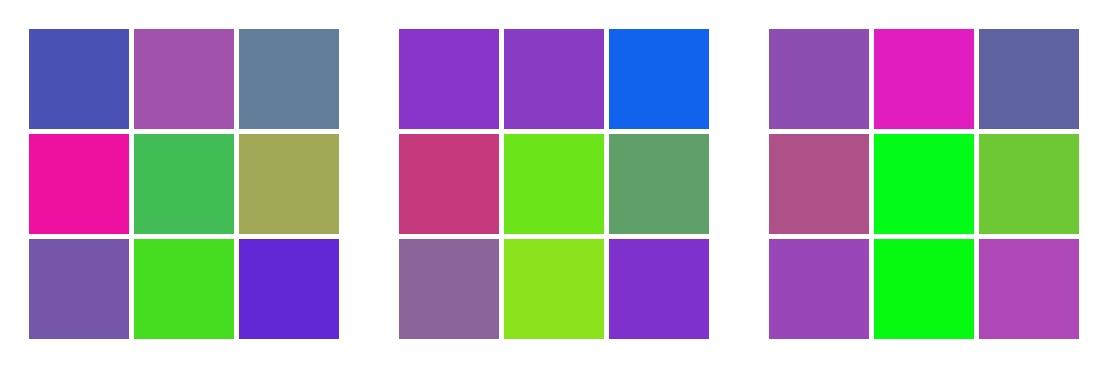

Utterances: speaker: bright pink middle left. This set has definite different colors, other 2 look like some shades are the same
listener: does it have almost the same shade of purple for top left and top middle square?
speaker: No. I said none of the colors are almost the same
Listener order: [1, 0, 2]
Target: 0
---


In [5]:
### grids

for i, entry in enumerate(entrys):
    print(f'Entry {i}:')
    img = build_grid_image(entry.objs, entry.listener_order, **img_kwargs)
    display(img)
    print(f'Utterances: {utterances_to_dialogue_string(entry.utterances)}')
    print(f'Listener order: {entry.listener_order}')
    print(f'Target: {entry.listener_order.index(entry.target)}')
    #print(f"Prediction: {predicted_targets[i] if i < len(predicted_targets) else 'N/A'}")
    print('---')

    if i >= 10:
        break

In [12]:
print(model.model.metadata)

AttributeError: 'OpenAI' object has no attribute 'model'

In [23]:
### patches

import io
import base64
import tqdm

success = list()
condition = list()
predicted_targets = list()

for i, entry in enumerate(tqdm.tqdm(entrys, desc="Evaluating entries")):
    img = build_patch_image_with_target_highlight(entry.hls_values, entry.l_order_t_distr1_distr2, **img_kwargs, highlight_target=False)

    description = utterances_to_dialogue_string(entry.conversation)

    judge_prompt = f"""
        You see an image with three color patches: left, middle, right.

        Description:
        "{description}"

        Which patch matches the description?

        Answer with exactly one word only:
        left, middle, or right.
        """

    #full_prompt = f"{prompt}\n{utterances_to_dialogue_string(entry.conversation)}\n{prompt_2}"

    

    # response_sentence = model.generate(
    #     judge_prompt,
    #     img,
    #     max_new_tokens=80,
    #     temperature=0.8,
    # )


    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    image_url = f"data:image/png;base64,{img_base64}"

    response = model.chat.completions.create(
        model="Qwen/Qwen3.6-27B-FP8",
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_url
                        }
                    },
                    {
                        "type": "text",
                        "text": judge_prompt
                    },
                ],
            }
        ],
        temperature=0.7,
        #max_tokens=800,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": True
            },
            "thinking_token_budget": 80
        }
    )

    response_sentence = response.choices[0].message.content
    #print(f"Thinking tokens used: {response.usage.completion_tokens}")

    if response_sentence is None:
        print(f"Warning: No response received for entry {i}. Skipping this entry.")
        continue
    #print(f"Response: {response_sentence.strip()}")

    condition.append(entry.condition)

    

    entry.target = entry.l_order_t_distr1_distr2.index(0)
    
    text = response_sentence.strip().lower()

    if "left" in text:
        predicted_target = 0
    elif "middle" in text:
        predicted_target = 1
    elif "right" in text:
        predicted_target = 2
    else:
        predicted_target = -1

    success.append(predicted_target == entry.target)
    predicted_targets.append(text)



Evaluating entries:   1%|          | 7/1000 [01:16<3:00:24, 10.90s/it]


KeyboardInterrupt: 

In [7]:
### patches batch

import io
import base64
import tqdm
import sys
import os
from os import path as osp
from openai import AsyncOpenAI
from tqdm.asyncio import tqdm_asyncio
import json
import argparse
import asyncio

success = list()
condition = list()
predicted_targets = list()
all_responses = list()

async def main():
    global success, condition, predicted_targets

    print("setup client...")
    
    client = AsyncOpenAI(
        api_key="EMPTY",
        base_url="http://0.0.0.0:8080/v1",
    )

    async def single_request(i, entry, semaphore):
        global success, condition, predicted_targets, all_responses
        async with semaphore:
            try:
                img = build_patch_image_with_target_highlight(entry.hls_values, entry.l_order_t_distr1_distr2, **img_kwargs, highlight_target=False)

                description = utterances_to_dialogue_string(entry.conversation)

                judge_prompt = f"""
                    You see an image with three color patches: left, middle, right.

                    Description:
                    "{description}"

                    Which patch matches the description?

                    Answer with exactly one word only:
                    left, middle, or right.
                    """

                #full_prompt = f"{prompt}\n{utterances_to_dialogue_string(entry.conversation)}\n{prompt_2}"

                

                #response_sentence = model.generate(full_prompt, img, **generate_kwargs)
                #response_sentence = model.generate(
                #    judge_prompt,
                #    img,
                #    max_new_tokens=80,
                #    temperature=0.8,
                #)


                buffer = io.BytesIO()
                img.save(buffer, format="PNG")
                img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

                image_url = f"data:image/png;base64,{img_base64}"

                response = await client.chat.completions.create(
                    model="Qwen/Qwen3.8-27B-FP8",
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {
                                    "type": "image_url",
                                    "image_url": {
                                        "url": image_url
                                    }
                                },
                                {
                                    "type": "text",
                                    "text": judge_prompt
                                },
                            ],
                        }
                    ],
                    temperature=1.0,
                    top_p=0.95,
                    presence_penalty=0.0,
                    max_tokens=800,
                    extra_body={
                        "chat_template_kwargs": {
                            "enable_thinking": True
                        },
                        "thinking_budget_tokens": 100,
                    }
                )

                response_sentence = response.choices[0].message.content
                #print(f"Thinking tokens used: {response.usage.completion_tokens}")

                if response_sentence is None:
                    print(f"Warning: No response received for entry {i}. Skipping this entry.")
                    return
                #print(f"Response: {response_sentence.strip()}")

                condition.append(entry.condition)

                all_responses.append(response)

                #entry.target = entry.l_order_t_distr1_distr2.index(entry.target)
                
                text = response_sentence.strip().lower()

                if "left" in text:
                    predicted_target = 0
                elif "middle" in text:
                    predicted_target = 1
                elif "right" in text:
                    predicted_target = 2
                else:
                    predicted_target = -1

                
                entry.target = entry.l_order_t_distr1_distr2.index(0)
                success.append(predicted_target == entry.target)
                predicted_targets.append(text)

                return text

            except Exception as e:
                print(f"Error processing entry {i}: {e}")
                return
            

    async def batch_requests():
        semaphore = asyncio.Semaphore(10)  # Limit to 10 concurrent requests
        tasks = []
        for i, entry in enumerate(entrys):
            tasks.append(single_request(i, entry, semaphore))
        return await tqdm_asyncio.gather(*tasks)

    all_responses = await batch_requests()

    return all_responses

responses_async = await main()

setup client...


100%|██████████| 1000/1000 [59:03<00:00,  3.54s/it] 


In [10]:
for response in all_responses:
    print(response.choices[0].message)
print(len(all_responses))

ChatCompletionMessage(content='left', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning_content='The user wants me to look at the image')
ChatCompletionMessage(content='right', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning_content='The user wants me to look at three color')
ChatCompletionMessage(content='left', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning_content='The user wants me to identify which color patch')
ChatCompletionMessage(content='right', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning_content='The user wants me to identify which color patch')
ChatCompletionMessage(content='right', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning_content='The user wants me to identify whi

Patches

Thinking 100
1:55h

no Thinking  
9:50min 



In [9]:
### grids

import io
import base64
import tqdm

success = list()
condition = list()
predicted_targets = list()

for i, entry in enumerate(tqdm.tqdm(entrys, desc="Evaluating entries")):
    img = build_grid_image(entry.objs, entry.listener_order, **img_kwargs)

    description = utterances_to_dialogue_string(entry.utterances)

    judge_prompt = f"""
        You see an image with three color grids: left, middle, right.

        Description:
        "{description}"

        Which grid matches the description?

        Answer with exactly one word only:
        left, middle, or right.
        """

    #full_prompt = f"{prompt}\n{utterances_to_dialogue_string(entry.conversation)}\n{prompt_2}"

    

    #response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    #response_sentence = model.generate(
    #    judge_prompt,
    #    img,
    #    max_new_tokens=80,
    #    temperature=0.8,
    #)


    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    image_url = f"data:image/png;base64,{img_base64}"

    response = model.chat.completions.create(
        model="Qwen/Qwen3.6-27B-FP8",
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_url
                        }
                    },
                    {
                        "type": "text",
                        "text": judge_prompt
                    },
                ],
            }
        ],
        temperature=0.7,
        #max_tokens=800,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": True
            }
        }
    )

    response_sentence = response.choices[0].message.content
    #print(f"Thinking tokens used: {response.usage.completion_tokens}")

    if response_sentence is None:
        print(f"Warning: No response received for entry {i}. Skipping this entry.")
        continue
    #print(f"Response: {response_sentence.strip()}")

    condition.append(entry.condition)

    

    #entry.target = entry.l_order_t_distr1_distr2.index(entry.target)
    
    text = response_sentence.strip().lower()

    if "left" in text:
        predicted_target = 0
    elif "middle" in text:
        predicted_target = 1
    elif "right" in text:
        predicted_target = 2
    else:
        predicted_target = -1

    success.append(predicted_target == entry.listener_order.index(entry.target))
    predicted_targets.append(text)



Evaluating entries:   0%|          | 0/1000 [00:00<?, ?it/s]


NotFoundError: Error code: 404 - {'error': {'message': 'The model `Qwen/Qwen3.6-27B-FP8` does not exist.', 'type': 'NotFoundError', 'param': 'model', 'code': 404}}

In [22]:
### grids

import io
import base64
import tqdm

success = list()
condition = list()
predicted_targets = list()

client = AsyncOpenAI(
        api_key="EMPTY",
        base_url="http://129.70.40.28:8000/v1",
    )

for i, entry in enumerate(tqdm.tqdm(entrys, desc="Evaluating entries")):
    img = build_grid_image(entry.objs, entry.listener_order, **img_kwargs)

    description = utterances_to_dialogue_string(entry.utterances)

    judge_prompt = f"""
        You see an image with three color grids: left, middle, right.

        Description:
        "{description}"

        Which grid matches the description?

        Answer with exactly one word only:
        left, middle, or right.
        """

    #full_prompt = f"{prompt}\n{utterances_to_dialogue_string(entry.conversation)}\n{prompt_2}"

    

    #response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    #response_sentence = model.generate(
    #    judge_prompt,
    #    img,
    #    max_new_tokens=80,
    #    temperature=0.8,
    #)


    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    image_url = f"data:image/png;base64,{img_base64}"

    response = model.chat.completions.create(
        model="Qwen/Qwen3.8-27B-FP8",
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_url
                        }
                    },
                    {
                        "type": "text",
                        "text": judge_prompt
                    },
                ],
            }
        ],
        temperature=0.7,
        #max_tokens=800,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    response_sentence = response.choices[0].message.content
    #print(f"Thinking tokens used: {response.usage.completion_tokens}")

    if response_sentence is None:
        print(f"Warning: No response received for entry {i}. Skipping this entry.")
        continue
    #print(f"Response: {response_sentence.strip()}")

    condition.append(entry.condition)

    

    #entry.target = entry.l_order_t_distr1_distr2.index(entry.target)
    
    text = response_sentence.strip().lower()

    if "left" in text:
        predicted_target = 0
    elif "middle" in text:
        predicted_target = 1
    elif "right" in text:
        predicted_target = 2
    else:
        predicted_target = -1

    success.append(predicted_target == entry.listener_order.index(entry.target))
    predicted_targets.append(text)



Evaluating entries: 100%|██████████| 1000/1000 [06:09<00:00,  2.71it/s]


In [ ]:
### grids batch

import io
import base64
import tqdm
import sys
import os
from os import path as osp
from openai import AsyncOpenAI
from tqdm.asyncio import tqdm_asyncio
import json
import argparse
import asyncio

success = list()
condition = list()
predicted_targets = list()

async def main():
    global success, condition, predicted_targets

    print("setup client...")
    
    client = AsyncOpenAI(
        api_key="EMPTY",
        base_url="http://0.0.0.0:8080/v1",
    )

    async def single_request(i, entry, semaphore):
        global success, condition, predicted_targets
        async with semaphore:
            try:
                img = build_grid_image(entry.objs, entry.listener_order, **img_kwargs)

                description = utterances_to_dialogue_string(entry.utterances)

                judge_prompt = f"""
                    You see an image with three color grids: left, middle, right.

                    Description:
                    "{description}"

                    Which grid matches the description?

                    Answer with exactly one word only:
                    left, middle, or right.
                    """

                #full_prompt = f"{prompt}\n{utterances_to_dialogue_string(entry.conversation)}\n{prompt_2}"

                

                #response_sentence = model.generate(full_prompt, img, **generate_kwargs)
                #response_sentence = model.generate(
                #    judge_prompt,
                #    img,
                #    max_new_tokens=80,
                #    temperature=0.8,
                #)


                buffer = io.BytesIO()
                img.save(buffer, format="PNG")
                img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

                image_url = f"data:image/png;base64,{img_base64}"

                response = await client.chat.completions.create(
                    model="Qwen/Qwen3.8-27B-FP8",
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {
                                    "type": "image_url",
                                    "image_url": {
                                        "url": image_url
                                    }
                                },
                                {
                                    "type": "text",
                                    "text": judge_prompt
                                },
                            ],
                        }
                    ],
                    temperature=1.0,
                    top_p=0.95,
                    presence_penalty=0.0,
                    max_tokens=800,
                    extra_body={
                        "chat_template_kwargs": {
                            "enable_thinking": False
                        },
                        "thinking_budget_tokens": 100,
                    }
                )

                response_sentence = response.choices[0].message.content
                #print(f"Thinking tokens used: {response.usage.completion_tokens}")

                if response_sentence is None:
                    print(f"Warning: No response received for entry {i}. Skipping this entry.")
                    return
                #print(f"Response: {response_sentence.strip()}")

                condition.append(entry.condition)

                

                #entry.target = entry.l_order_t_distr1_distr2.index(entry.target)
                
                text = response_sentence.strip().lower()

                if "left" in text:
                    predicted_target = 0
                elif "middle" in text:
                    predicted_target = 1
                elif "right" in text:
                    predicted_target = 2
                else:
                    predicted_target = -1

                success.append(predicted_target == entry.listener_order.index(entry.target))
                predicted_targets.append(text)

                return text

            except Exception as e:
                print(f"Error processing entry {i}: {e}")
                return
                

    async def batch_requests():
        semaphore = asyncio.Semaphore(10)  # Limit to 10 concurrent requests
        tasks = []
        for i, entry in enumerate(entrys):
            tasks.append(single_request(i, entry, semaphore))
        return await tqdm_asyncio.gather(*tasks)

    all_responses = await batch_requests()

    return all_responses

responses_async = await main()

setup client...


100%|██████████| 1000/1000 [1:23:05<00:00,  4.99s/it]


In [ ]:
#predicted_targets_backup = predicted_targets.copy()  ## 80min für 70 patches
#predicted_targets_backup = predicted_targets.copy()  ## 80min für 70 patches
#success_backup = success.copy()  ## 80min für 70 patches
#condition_backup = condition.copy()  ## 80min für 70 patches
print(len(predicted_targets))
print(len(success))

556
556


In [35]:
!ping 129.70.40.28

PING 129.70.40.28 (129.70.40.28) 56(84) bytes of data.
64 bytes from 129.70.40.28: icmp_seq=1 ttl=61 time=19.5 ms
64 bytes from 129.70.40.28: icmp_seq=2 ttl=61 time=19.6 ms
64 bytes from 129.70.40.28: icmp_seq=3 ttl=61 time=21.1 ms

--- 129.70.40.28 ping statistics ---
4 packets transmitted, 3 received, 25% packet loss, time 3021ms
rtt min/avg/max/mdev = 19.469/20.069/21.122/0.746 ms
^C


In [8]:
from openai import OpenAI

client = OpenAI(
    api_key="EMPTY",
    base_url="http://0.0.0.0:8080/v1",
)

response = client.chat.completions.create(
    model="Qwen/Qwen3.8-27B-FP8",
    messages=[
        {
            "role": "user",
            "content": "Beschreibe die Farbe Türkis in max 3 Sätzen"
        }
    ],
    temperature=1.0,
    top_p=0.95,
    presence_penalty=0.0,
    max_tokens=800,
    extra_body={
        "chat_template_kwargs": {
            "enable_thinking": False
        },
        "top_topdfasf": 20,
        "min_p": 0.0,
        "repetition_penalty": 1.0,
    }
)

print(response.choices[0].message.content)

Türkis ist eine leuchtende, kühle Farbe, die sich durch das Mischen von Blau und Grün ergibt. Sie wird oft mit klarem Wasser, tropischen Meeren und einem Gefühl von Frische sowie Erfrischung assoziiert. Als Farbton zwischen Cyan und Blau strahlt sie eine vibrierende Energie und Leichtigkeit aus.


In [1]:
import llama_cpp
print(llama_cpp.llama_print_system_info().decode())

ggml_cuda_init: found 1 CUDA devices (Total VRAM: 24575 MiB):
  Device 0: NVIDIA GeForce RTX 3090, compute capability 8.6, VMM: yes, VRAM: 24575 MiB


CUDA : ARCHS = 860 | USE_GRAPHS = 1 | PEER_MAX_BATCH_SIZE = 128 | CPU : SSE3 = 1 | SSSE3 = 1 | AVX = 1 | AVX2 = 1 | F16C = 1 | FMA = 1 | BMI2 = 1 | LLAMAFILE = 1 | OPENMP = 1 | REPACK = 1 | 


In [15]:
!CMAKE_ARGS="-DGGML_CUDA=on" FORCE_CMAKE=1 \
pip install --no-cache-dir --force-reinstall llama-cpp-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 MB 7.3 MB/s  0:00:09m0:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 8.0 MB/s  0:00:02 eta 0:00:01
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.33-py3-none-linux_x86_64.whl size=212940380 sha256=88fae35b0eaa998db7bc34615ce0282dae9ea317575160e001acb92a8f6afcb9
  Stored in directory: /tmp/pip-ephem-wheel-cache-0fcs2mw1/wheels/30/40/69/34103e5e0d61f9ff90a2882dd18ec493a0210ef006e657b98f
Successfully built llama-cpp-python
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.032m0/6 [typing-extensions]
  Attempting uninstall: numpy━━━━━━━━━━━━━━━ 0/6 [typing-extensions]
    Found existing installation: numpy 2.4.3 0/6

In [10]:
len(predicted_targets)

371

for i in range(10):
    img = 

In [7]:
true = 0
false = 0

true_close = 0
true_far = 0
true_split = 0
false_close = 0
false_far = 0
false_split = 0

for i in range(1000):

    if success[i] == True:
        if condition[i].lower() == "close":
            true_close += 1
        elif condition[i].lower() == "far":
            true_far += 1
        elif condition[i].lower() == "split":
            true_split += 1
        true += 1
        #print(f"Entry {i} succeeded. Condition: {condition[i]}, Target: {entrys[i].target}, Predicted: {predicted_targets[i]}")
    else:
        false += 1
        if condition[i].lower() == "close":
            false_close += 1
        elif condition[i].lower() == "far":
            false_far += 1
        elif condition[i].lower() == "split":
            false_split += 1
        #print(f"Entry {i} failed. Condition: {condition[i]}, Target: {entrys[i].target}, Predicted: {predicted_targets[i]}")
        #print(f"Utterances: {utterances_to_dialogue_string(entrys[i].conversation)}")
        #display(build_patch_image_with_target_highlight(entrys[i].hls_values, entrys[i].l_order_t_distr1_distr2, **img_kwargs, highlight_target=False))
        #print('---')
        
#print(f"True Far: {true_far}, False Far: {false_far}")
print(f"True: {true}, False: {false}")
print(f"Accuracy: {true/(true+false)}")
print(f"True Far: {true_far}, False Far: {false_far}, Accuracy Far: {true_far/(true_far+false_far)}")
print(f"True Split: {true_split}, False Split: {false_split}, Accuracy Split: {true_split/(true_split+false_split)}")
print(f"True Close: {true_close}, False Close: {false_close}, Accuracy Close: {true_close/(true_close+false_close)}")

True: 715, False: 285
Accuracy: 0.715
True Far: 255, False Far: 93, Accuracy Far: 0.7327586206896551
True Split: 233, False Split: 85, Accuracy Split: 0.7327044025157232
True Close: 227, False Close: 107, Accuracy Close: 0.6796407185628742


Patches

Qwen 2(2B) -- 3 min

True: 253, False: 247   
Accuracy: 0.506   
True Far: 104, False Far: 72, Accuracy Far: 0.5909090909090909  
True Split: 85, False Split: 89, Accuracy Split: 0.4885057471264368  
True Close: 64, False Close: 86, Accuracy Close: 0.4266666666666667  

.

Qwen 2(7B) -- 7 min

True: 409, False: 91    
Accuracy: 0.818  
True Far: 168, False Far: 8, Accuracy Far: 0.9545454545454546  
True Split: 143, False Split: 31, Accuracy Split: 0.8218390804597702  
True Close: 98, False Close: 52, Accuracy Close: 0.6533333333333333  

.

Qwen 3(2B) -- 3 min

True: 280, False: 220  
Accuracy: 0.56  
True Far: 113, False Far: 63, Accuracy Far: 0.6420454545454546  
True Split: 100, False Split: 74, Accuracy Split: 0.5747126436781609  
True Close: 67, False Close: 83, Accuracy Close: 0.44666666666666666  

.

Qwen 3.5(0.8B)  --5 min

True: 182, False: 318  
Accuracy: 0.364  
True Far: 68, False Far: 108, Accuracy Far: 0.38636363636363635  
True Split: 68, False Split: 106, Accuracy Split: 0.39080459770114945  
True Close: 46, False Close: 104, Accuracy Close: 0.30666666666666664  

.

Qwen 3.5(4B)  --7 min

True: 380, False: 120  
Accuracy: 0.76  
True Far: 146, False Far: 30, Accuracy Far: 0.8295454545454546  
True Split: 134, False Split: 40, Accuracy Split: 0.7701149425287356  
True Close: 100, False Close: 50, Accuracy Close: 0.6666666666666666  

.

Qwen 3.5(9B)  --10min

True: 447, False: 53  
Accuracy: 0.894  
True Far: 163, False Far: 13, Accuracy Far: 0.9261363636363636  
True Split: 158, False Split: 16, Accuracy Split: 0.9080459770114943  
True Close: 126, False Close: 24, Accuracy Close: 0.84  

.

Qwen 3.5(27B 4Q) --45min

True: 437, False: 63  
Accuracy: 0.874  
True Far: 162, False Far: 14, Accuracy Far: 0.9204545454545454  
True Split: 154, False Split: 20, Accuracy Split: 0.8850574712643678  
True Close: 121, False Close: 29, Accuracy Close: 0.8066666666666666  


___________________________________________________________________________

Qwen 3.6(27b 8bit) -no Thinking --5min

True: 455, False: 45  
Accuracy: 0.91  
True Far: 168, False Far: 8, Accuracy Far: 0.9545454545454546  
True Split: 157, False Split: 17, Accuracy Split: 0.9022988505747126  
True Close: 130, False Close: 20, Accuracy Close: 0.8666666666666667  

.

Qwen 3.6(27b 8bit) -40 Token Thinking -32min

True: 459, False: 41  
Accuracy: 0.918  
True Far: 168, False Far: 8, Accuracy Far: 0.9545454545454546  
True Split: 161, False Split: 13, Accuracy Split: 0.9252873563218391  
True Close: 130, False Close: 20, Accuracy Close: 0.8666666666666667  

.

Qwen 3.6(27b 8bit) -100 Token Thinking -47min

True: 467, False: 33  
Accuracy: 0.934  
True Far: 170, False Far: 6, Accuracy Far: 0.9659090909090909  
True Split: 165, False Split: 9, Accuracy Split: 0.9482758620689655  
True Close: 132, False Close: 18, Accuracy Close: 0.88  

.

Qwen 3.6(27b 8bit) -300 Token Thinking -120min

True: 473, False: 27  
Accuracy: 0.946  
True Far: 171, False Far: 5, Accuracy Far: 0.9715909090909091  
True Split: 166, False Split: 8, Accuracy Split: 0.9540229885057471  
True Close: 136, False Close: 14, Accuracy Close: 0.9066666666666666  


______________________________________________________________________

Qwen 3.8(27b 3bit) -100 Token Thinking -60min

True: 900, False: 100
Accuracy: 0.9
True Far: 342, False Far: 23, Accuracy Far: 0.936986301369863
True Split: 313, False Split: 33, Accuracy Split: 0.9046242774566474
True Close: 245, False Close: 44, Accuracy Close: 0.8477508650519031


# Grids

Qwen 3.6(27b 8bit) -no Thinking --5min  

True: 394, False: 106  
Accuracy: 0.788  
True Far: 135, False Far: 26, Accuracy Far: 0.8385093167701864  
True Split: 130, False Split: 43, Accuracy Split: 0.7514450867052023  
True Close: 129, False Close: 37, Accuracy Close: 0.7771084337349398  

.

Qwen 3.6(27b 8bit) -100 Token Thinking -60min 

True: 382, False: 118
Accuracy: 0.764
True Far: 133, False Far: 28, Accuracy Far: 0.8260869565217391
True Split: 128, False Split: 45, Accuracy Split: 0.7398843930635838
True Close: 121, False Close: 45, Accuracy Close: 0.7289156626506024

.

Qwen 3.8(27b 8bit) - Thinking -20min  

True: 498, False: 2  
Accuracy: 0.996  
True Far: 220, False Far: 0, Accuracy Far: 1.0  
True Split: 154, False Split: 1, Accuracy Split: 0.9935483870967742  
True Close: 124, False Close: 1, Accuracy Close: 0.992  


____________________________________________________________________________


Qwen 3.6(27b 3bit) -100 Token Thinking -80min  

True: 715, False: 285  
Accuracy: 0.715  
True Far: 255, False Far: 93, Accuracy Far: 0.7327586206896551  
True Split: 233, False Split: 85, Accuracy Split: 0.7327044025157232  
True Close: 227, False Close: 107, Accuracy Close: 0.6796407185628742  



# Patches 

GPU Speicher -- 24GB  
Leerlauf -- 1.1 GB  
Background (Trainingsmodell Qwen 2 2B) -- 4.5 GB  
0.8B -- 1.6GB
4B -- 8.7GB  
9B -- 17.9GB  
BERTScorer -- 1.1GB  


4b -- 6min -- 9.9GB  
4b + Background -- 6min -- 14.2GB  
4b + Backgorund + BERT --6min -- 15.0 GB  


9b -- 6min -- 19.4GB  
Background + 9b -- 35min -- 23GB (Background komplett in GPU, 9B teilweise auf CPU)  
9b + Background -- 7min -- 23GB (9B komplett in GPU, Background teilweise auf CPU)  


True: 862, False: 138  
Accuracy: 0.862  
True Far: 337, False Far: 28, Accuracy Far: 0.9232876712328767  
True Split: 302, False Split: 44, Accuracy Split: 0.8728323699421965  
True Close: 223, False Close: 66, Accuracy Close: 0.7716262975778547  